# Model Diagnostics

Residual plots, Cook's distance, leverage, and learning curves for the engineered-feature OLS model.


In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from house_price_predictor import LeastSquaresRegressor, build_feature_frame, load_housing_data, train_val_split
from house_price_predictor.diagnostics import residuals, cook_distance, leverage_approx, learning_curve_rmse, diagnostics_summary

train, _ = load_housing_data()
eng, _ = build_feature_frame(train, log_target=True)
X, y = eng.X, eng.y
X_tr, X_va, y_tr, y_va = train_val_split(X, y, random_state=42)
model = LeastSquaresRegressor().fit(X_tr, y_tr)
pred = model.predict(X_va)
print(diagnostics_summary(y_va, pred, X_va))


{'residual_mean': 0.009724111760284407, 'residual_std': 0.12825177747732708, 'max_abs_residual': 0.8124904203693468, 'max_cooks_distance': 0.25725849160919423, 'n_high_leverage': 21}


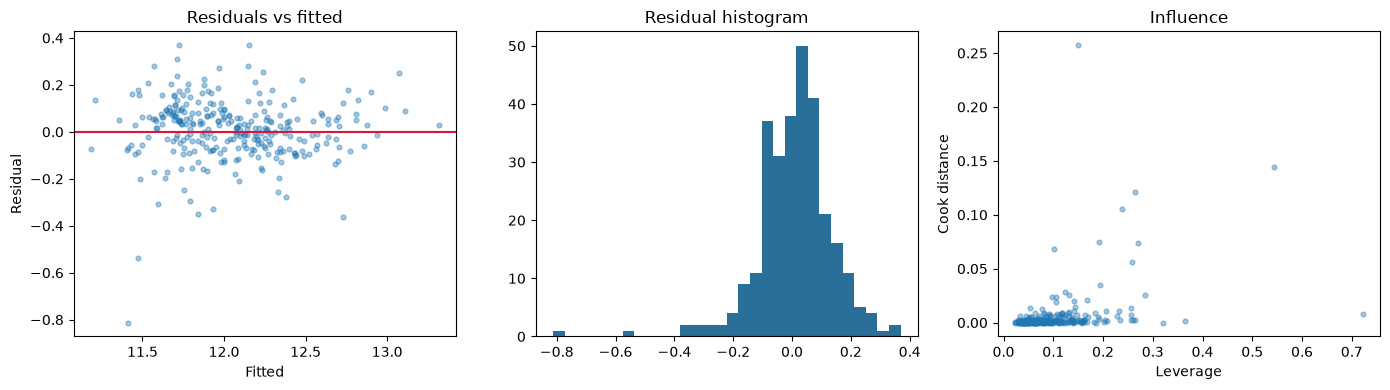

In [2]:
r = residuals(y_va, pred)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].scatter(pred, r, alpha=0.4, s=12)
axes[0].axhline(0, color="crimson"); axes[0].set_xlabel("Fitted"); axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs fitted")
axes[1].hist(r, bins=30, color="#2a6f97"); axes[1].set_title("Residual histogram")
h = leverage_approx(X_va); c = cook_distance(y_va, pred, X_va)
axes[2].scatter(h, c, alpha=0.4, s=12)
axes[2].set_xlabel("Leverage"); axes[2].set_ylabel("Cook distance"); axes[2].set_title("Influence")
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "diagnostics_residuals.png", dpi=120)
plt.show()


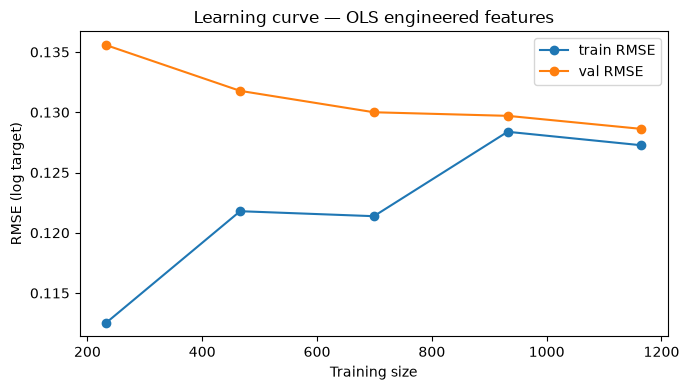

In [3]:
sizes, tr, va = learning_curve_rmse(LeastSquaresRegressor, X, y)
plt.figure(figsize=(7,4))
plt.plot(sizes, tr, marker="o", label="train RMSE")
plt.plot(sizes, va, marker="o", label="val RMSE")
plt.xlabel("Training size"); plt.ylabel("RMSE (log target)"); plt.legend()
plt.title("Learning curve — OLS engineered features")
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "diagnostics_learning_curve.png", dpi=120)
plt.show()
